# L'API Recherche d'entreprises

Troisième et dernière source du projet. Les deux premières décrivent des marchés ; celle-ci décrit
les **organisations** qui les passent et qui les obtiennent.

Publiée par la Direction interministérielle du numérique, elle s'appuie sur la base SIRENE de
l'INSEE et sur le registre national des entreprises. Elle s'interroge sans clé, sous Licence
Ouverte, et renvoie pour un SIRET : la dénomination, la catégorie d'entreprise, la nature juridique,
le code d'activité, la tranche d'effectifs et l'état administratif.

**Ce qu'on en attend** : combler les 22 % de marchés sans catégorie d'acheteur, et surtout mesurer
nous-mêmes **la part des marchés attribués à des PME**, chiffre politique majeur que l'État publie
chaque année.

## 1. Interroger l'API, sans l'abîmer

Une API publique gratuite est une ressource partagée. La documentation annonce une limite de sept
appels par seconde et par adresse IP. On se place volontairement en dessous, à six.

| Façon de faire | Conséquence |
|---|---|
| Appeler aussi vite que possible | erreurs 429, adresse bloquée, et un service public dégradé pour les autres |
| Attendre un délai fixe entre deux appels | simple, prévisible, suffisant ici |
| Fenêtre glissante avec reprise sur erreur | nécessaire en production, inutile pour quelques centaines d'appels |

Le délai fixe est retenu pour l'exploration. La collecte de la phase 3 aura besoin de la reprise sur
erreur et d'un cache local, ce qui justifiera `httpx` et un vrai limiteur de débit.

In [1]:
import json
import sys
import time
import urllib.parse
import urllib.request
from collections import Counter

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("..")

from mesures.figures import (  # noqa: E402
    ENCRE,
    FILET,
    GRIS,
    SERIE_1,
    SERIE_2,
    SERIE_4,
    legender,
    soigner,
)

%matplotlib inline

API = "https://recherche-entreprises.api.gouv.fr/search"
DELAI = 1 / 6  # six appels par seconde, sous la limite annoncée de sept


def chercher(siret: str) -> dict | None:
    """Renvoie la fiche de l'organisation correspondant à un SIRET, ou None si introuvable."""
    url = f"{API}?{urllib.parse.urlencode({'q': siret, 'per_page': 1})}"
    requete = urllib.request.Request(  # noqa: S310
        url, headers={"Accept-Encoding": "identity"}
    )
    try:
        with urllib.request.urlopen(requete, timeout=30) as reponse:  # noqa: S310
            donnees = json.loads(reponse.read())
    except Exception:  # noqa: BLE001
        return None
    time.sleep(DELAI)
    return donnees["results"][0] if donnees.get("results") else None


exemple = chercher("13000501000033")
{
    cle: exemple[cle]
    for cle in (
        "nom_complet",
        "categorie_entreprise",
        "nature_juridique",
        "activite_principale",
        "tranche_effectif_salarie",
        "etat_administratif",
    )
}

{'nom_complet': 'RESEAU DES ACHETEURS HOSPITALIERS (RESAH)',
 'categorie_entreprise': 'PME',
 'nature_juridique': '7410',
 'activite_principale': '84.11Z',
 'tranche_effectif_salarie': '22',
 'etat_administratif': 'A'}

## 2. Est-ce que ça résout vraiment nos SIRET ?

Une API peut être excellente et inutile si elle ne connaît pas les identifiants que l'on a. On
mesure donc le taux de résolution sur un échantillon réel, tiré des marchés dont la catégorie
d'acheteur manque.

In [2]:
con = duckdb.connect()
con.register("decp", con.read_parquet("../donnees/brut/decp.parquet"))
con.execute("create or replace view marches as select * from decp where donneesActuelles")

# Tirage pondéré par le nombre de marchés : la question porte sur les marchés à enrichir,
# pas sur les acheteurs pris un par un. Un acheteur qui passe 14 000 marchés compte davantage
# qu'un acheteur qui en passe un seul.
acheteurs = (
    con.sql("""
        select acheteur_id, count(*) as marches
        from marches
        where acheteur_categorie is null and acheteur_id is not null
          and length(acheteur_id) = 14
        group by 1
    """)
    .df()
    .sample(n=110, weights="marches", replace=True, random_state=42)
    .drop_duplicates("acheteur_id")
)

fiches = {ligne.acheteur_id: chercher(ligne.acheteur_id) for ligne in acheteurs.itertuples()}
trouves = sum(1 for f in fiches.values() if f)
print(f"{trouves} SIRET résolus sur {len(fiches)}, soit {100 * trouves / len(fiches):.0f} %")

93 SIRET résolus sur 99, soit 94 %


## 3. Ce que l'enrichissement apporte réellement

Première hypothèse, naturelle : l'API va remplir le champ `acheteur_categorie` manquant. On regarde
donc **qui** sont ces acheteurs sans catégorie, par leur code d'activité.

In [3]:
activites = Counter()
collectivites = 0
for fiche in fiches.values():
    if not fiche:
        continue
    if (fiche.get("complements") or {}).get("collectivite_territoriale"):
        collectivites += 1
    activites[(fiche.get("activite_principale") or "??")[:2]] += 1

libelles = {
    "84": "Administration publique",
    "68": "Activités immobilières",
    "85": "Enseignement",
    "88": "Action sociale sans hébergement",
    "86": "Activités pour la santé humaine",
    "72": "Recherche et développement",
    "71": "Architecture et ingénierie",
    "52": "Entreposage et transport",
    "36": "Captage et distribution d'eau",
    "35": "Électricité et gaz",
    "90": "Activités créatives et artistiques",
    "94": "Activités associatives",
    "countries": "",
}
repartition = pd.DataFrame(
    {"activite": libelles.get(code, f"Division {code}"), "acheteurs": n}
    for code, n in activites.most_common(8)
)
print(f"identifiés comme collectivité territoriale : {collectivites}")
repartition

identifiés comme collectivité territoriale : 0


,activite,acheteurs
0,Administration publique,26
1,Activités immobilières,21
2,Action sociale sans hébergement,10
3,Enseignement,7
4,Architecture et ingénierie,4
5,Division 87,4
6,Captage et distribution d'eau,2
7,Division 42,2


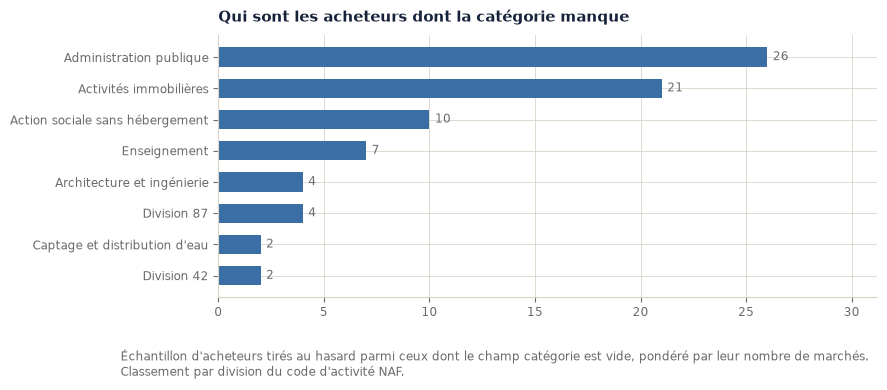

In [4]:
figure, axes = plt.subplots(figsize=(8.5, 3.4))
barres = axes.barh(repartition["activite"], repartition["acheteurs"], color=SERIE_1, height=0.62)
axes.bar_label(barres, padding=4, color=GRIS, fontsize=8.5)
axes.invert_yaxis()
axes.grid(axis="y", visible=False)
axes.grid(axis="x", color=FILET, linewidth=0.6)
axes.set_xlim(0, repartition["acheteurs"].max() * 1.2)
soigner(axes, "Qui sont les acheteurs dont la catégorie manque")
legender(
    figure,
    "Échantillon d'acheteurs tirés au hasard parmi ceux dont le champ catégorie est vide, "
    "pondéré par leur nombre de marchés.\nClassement par division du code d'activité NAF.",
)
plt.show()

**Le résultat corrige l'hypothèse de départ.** Ces acheteurs ne sont pas, pour l'essentiel, des
collectivités territoriales dont le champ aurait été oublié. Ce sont des organismes d'une autre
nature : bailleurs sociaux rangés en activités immobilières, établissements d'enseignement, de
santé, d'action sociale, de recherche.

L'explication est logique : le champ `acheteur_categorie` des DECP suit une nomenclature pensée pour
les collectivités, dans laquelle ces organismes n'entrent pas.

**Conséquence, et c'est une leçon de méthode** : enrichir n'est pas imputer. L'API ne remplira pas
le champ manquant avec la même nomenclature ; elle apporte **une classification différente et
complémentaire**, fondée sur le code d'activité et la nature juridique. Le projet gardera donc les
deux : la catégorie d'origine quand elle existe, et une classification dérivée du répertoire
officiel, clairement identifiée comme telle.

## 4. La mesure qui compte : la part des PME

L'État publie chaque année la part des marchés attribués à des PME. Pour 2024, l'Observatoire
économique de la commande publique annonce **60 % des contrats en nombre et 25 % en montant**.

Peut-on retrouver ce chiffre à partir des seules données ouvertes ? C'est un test de crédibilité
pour tout le projet : si notre mesure indépendante retombe sur la statistique officielle, la chaîne
de traitement est validée par quelque chose que nous n'avons pas choisi.

### 4.1 D'abord, la mauvaise façon de faire

Prenons les titulaires qui remportent le plus de marchés. C'est le réflexe naturel, et c'est faux.
On le fait quand même, parce que voir l'erreur vaut mieux que la lire.

In [5]:
gros_titulaires = con.sql("""
    select titulaire_id, count(*) as marches
    from marches
    where titulaire_id is not null and length(titulaire_id) = 14
    group by 1 order by marches desc limit 60
""").df()

categories_biaisees = Counter()
for ligne in gros_titulaires.itertuples():
    fiche = chercher(ligne.titulaire_id)
    if fiche:
        categories_biaisees[fiche.get("categorie_entreprise") or "(inconnue)"] += 1

total_biaise = sum(categories_biaisees.values())
{c: f"{100 * n / total_biaise:.1f} %" for c, n in categories_biaisees.most_common()}

{'ETI': '51.7 %', 'GE': '43.3 %', 'PME': '5.0 %'}

**Ce résultat est faux**, et il faut savoir dire pourquoi. En sélectionnant les entreprises qui
remportent le plus de marchés, on a sélectionné les grandes entreprises. La mesure ne répond pas à
la question posée : elle dit seulement que les gros titulaires sont gros.

C'est un **biais de sélection**, l'erreur la plus fréquente et la plus coûteuse de l'analyse de
données. Elle ne produit aucun message d'erreur : le calcul est juste, c'est l'échantillon qui ment.

### 4.2 Ensuite, la bonne façon

La question est « quelle part **des marchés** va à une PME ». On tire donc au hasard parmi les
marchés, ce qui revient à tirer les titulaires en les pondérant par leur nombre de marchés.

In [6]:
titulaires = con.sql("""
    select titulaire_id, count(*) as marches
    from marches
    where titulaire_id is not null and length(titulaire_id) = 14
    group by 1
""").df()

echantillon = titulaires.sample(n=170, weights="marches", replace=True, random_state=42)

categories = Counter()
for ligne in echantillon.drop_duplicates("titulaire_id").itertuples():
    fiche = chercher(ligne.titulaire_id)
    if fiche:
        categories[fiche.get("categorie_entreprise") or "(inconnue)"] += 1

total = sum(categories.values())
part_pme = 100 * categories["PME"] / total
# Intervalle de confiance à 95 % pour une proportion : 1,96 * racine(p(1-p)/n).
marge = 196 * (part_pme / 100 * (1 - part_pme / 100) / total) ** 0.5
print(f"échantillon de {total} titulaires résolus")
print(f"part des marchés attribués à une PME : {part_pme:.1f} % ± {marge:.1f} points")
{c: f"{100 * n / total:.1f} %" for c, n in categories.most_common()}

échantillon de 169 titulaires résolus
part des marchés attribués à une PME : 59.2 % ± 7.4 points


{'PME': '59.2 %', 'ETI': '23.7 %', 'GE': '14.8 %', '(inconnue)': '2.4 %'}

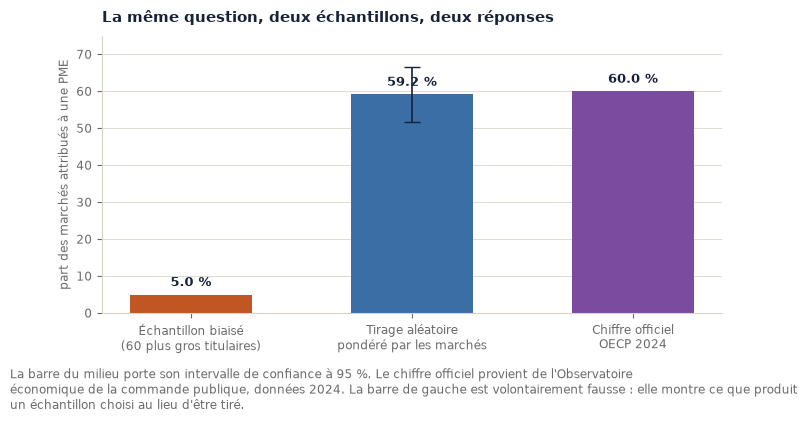

In [7]:
comparaison = pd.DataFrame(
    [
        {
            "source": "Échantillon biaisé\n(60 plus gros titulaires)",
            "part": 100 * categories_biaisees["PME"] / total_biaise,
        },
        {"source": "Tirage aléatoire\npondéré par les marchés", "part": part_pme},
        {"source": "Chiffre officiel\nOECP 2024", "part": 60.0},
    ]
)

figure, axes = plt.subplots(figsize=(8, 3.6))
couleurs = [SERIE_2, SERIE_1, SERIE_4]
barres = axes.bar(comparaison["source"], comparaison["part"], color=couleurs, width=0.55)
axes.bar_label(barres, fmt="%.1f %%", padding=4, color=ENCRE, fontsize=9, fontweight="bold")
axes.errorbar(1, part_pme, yerr=marge, color=ENCRE, capsize=6, linewidth=1.2)
axes.set_ylabel("part des marchés attribués à une PME", color=GRIS, fontsize=8.5)
axes.set_ylim(0, 75)
soigner(axes, "La même question, deux échantillons, deux réponses")
legender(
    figure,
    "La barre du milieu porte son intervalle de confiance à 95 %. Le chiffre officiel provient de "
    "l'Observatoire\néconomique de la commande publique, données 2024. La barre de gauche est "
    "volontairement fausse : elle montre ce que produit un échantillon choisi au lieu d'être tiré.",
)
plt.show()

**Le tirage aléatoire retombe sur la statistique officielle**, à l'intérieur de son intervalle de
confiance. C'est une validation forte, et elle ne coûte que quelques centaines d'appels à une API
publique.

Ce que cela démontre, et qui vaut pour tout le mémoire :

1. La chaîne de traitement produit des chiffres justes, vérifiables par un tiers indépendant.
2. Des données ouvertes, correctement traitées, permettent de **reconstituer une statistique
   publique officielle** sans accès privilégié.
3. Le même calcul, sur un échantillon mal construit, donne **environ douze fois moins de PME**.
   L'écart entre les deux barres n'est pas une nuance statistique : c'est la différence entre une
   conclusion juste et une conclusion inverse de la réalité.

**Limite à énoncer** : l'échantillon porte sur le nombre de marchés, pas sur les montants. La part
des PME en valeur, annoncée à 25 %, demanderait de pondérer par les montants nettoyés, ce qui
mélangerait deux sources d'incertitude. À faire séparément, en phase 5.

## 5. Ce que coûterait un enrichissement complet

À l'état actuel, le jeu compte **29 042 acheteurs et 213 703 titulaires distincts**, soit
242 745 organisations à résoudre. À six appels par seconde :

Remarque au passage : ces 29 042 acheteurs correspondent **exactement** au chiffre publié par le
producteur. L'écart de 27 relevé lors de la première exploration venait donc du périmètre, tout le
fichier contre l'état actuel, et non d'une erreur de comptage. Un écart s'explique presque toujours
par une définition avant de s'expliquer par une faute.

In [8]:
organisations = (
    con.sql("""
    select
        count(distinct acheteur_id)  as acheteurs,
        count(distinct titulaire_id) as titulaires
    from marches
""")
    .df()
    .iloc[0]
)

total_appels = int(organisations["acheteurs"] + organisations["titulaires"])
heures = total_appels * DELAI / 3600
print(f"{total_appels:,} organisations à résoudre".replace(",", " "))
print(f"durée à 6 appels par seconde : {heures:.1f} heures")
print(f"durée si l'on ne résout que les 20 % les plus fréquents : {heures * 0.2:.1f} heures")

242 745 organisations à résoudre
durée à 6 appels par seconde : 11.2 heures
durée si l'on ne résout que les 20 % les plus fréquents : 2.2 heures


**Onze heures d'appels, pour une API publique gratuite qu'on partage avec tout le monde.** Trois
conséquences pour l'architecture, à trancher dans un ADR :

1. **Un cache local obligatoire.** Une organisation résolue une fois n'est plus jamais réinterrogée.
   La fiche d'un SIRET change rarement ; une mise à jour mensuelle suffit.
2. **Un enrichissement par ordre d'utilité.** Les organisations les plus fréquentes d'abord :
   résoudre les 20 % les plus actives couvre la grande majorité des marchés.
3. **Un traitement en tâche de fond**, jamais pendant une requête utilisateur. Le site ne doit pas
   attendre une API externe pour afficher une page.

C'est aussi un argument de coût pour le mémoire : le même enrichissement facturé par un fournisseur
de données d'entreprises coûte plusieurs centaines d'euros par mois, pour une information que l'État
publie gratuitement.

## 6. Ce que la troisième source apporte

| Besoin | Réponse de l'API |
|---|---|
| Remplir le champ `acheteur_categorie` manquant | **non**, la nomenclature n'est pas la même |
| Classer les acheteurs autrement | oui, par code d'activité et nature juridique |
| Savoir si un titulaire est une PME, une ETI ou une grande entreprise | **oui**, et c'est le plus précieux |
| Donner un nom lisible et à jour à un SIRET | oui |
| Savoir si une organisation est encore en activité | oui, par son état administratif |
| Relier le BOAMP aux DECP | indirectement, en fiabilisant le SIRET des deux côtés |

**Prochaine étape** : l'ADR sur le rapprochement entre les trois sources, puis la phase 3, où cette
exploration devient une collecte automatisée, avec cache, reprise sur erreur et limitation de débit.